# GeoClip Italy -- Fine-Tuning (ItalyDataset)

Fine-tunes GeoCLIP on the pre-filtered Italy dataset produced by `Italy_Dataset_Builder.ipynb`.
Images are loaded from three compact region TAR archives (Nord / Centro / Sud_Isole) on Drive
and extracted to Colab local disk on demand.

## Run Guide

| # | Section | When to run |
|---|---------|-------------|
| 1 | Setup | Every session |
| 2 | Dataset | Every session (safe to re-run; already-extracted images are skipped) |
| 3 | Model & Optimizer | Every session |
| 4 | Training | Main loop -- resumable |
| 5 | Evaluation | After training |

**Resume training**: set `LOAD_CHECKPOINT = True` and point `CHECKPOINT_PATH` to the latest checkpoint.  
**New images added to dataset**: re-run `Italy_Dataset_Builder.ipynb` first, then re-run Sections 2 and 3 here.

## Section 1 -- Setup

Run cells 2-4 at the start of every session.

In [1]:
# Install -- run every session
%pip install -q geoclip pandas torch torchvision tqdm scikit-learn peft global-land-mask
%pip install -q folium seaborn matplotlib Pillow geopy
%pip uninstall -y -q torchao
print("Packages ready.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 MB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 37.6 MB/s eta 0:00:00
Packages ready.


In [2]:
import os

# ============================================================
# GLOBAL CONFIGURATION -- edit only this cell
# ============================================================

# Google Drive base
DRIVE_BASE = "/content/drive/MyDrive/Vision_Project_2026"

# OSV5M Italy dataset (produced by osv5m/osv5m_dataset_preprocess.ipynb)
OSV5M_BASE           = f"{DRIVE_BASE}/osv5m/osv5m_italy_dataset"
DRIVE_TRAIN_META_CSV = f"{OSV5M_BASE}/train_images/train_metadata.csv"
DRIVE_TEST_META_CSV  = f"{OSV5M_BASE}/test_images/test_metadata.csv"
DRIVE_TRAIN_TAR_DIR  = f"{OSV5M_BASE}/train_subdirtars"
DRIVE_TEST_TAR_DIR   = f"{OSV5M_BASE}/test_subdirtars"

# Runtime image dirs (populated by the deploy cell below)
RUNTIME_TRAIN_DIR = "/content/osv5m_images/train"
RUNTIME_TEST_DIR  = "/content/osv5m_images/test"

# Must match osv5m_dataset_preprocess.ipynb
NUM_BUCKETS = 20

# checkpoints_v3_2: new dir because LoRA rank/targets changed vs V3.1 (rank 16, 4 targets)
DRIVE_CHECKPOINT_DIR = f"{DRIVE_BASE}/checkpoints_v3_2"
os.makedirs(DRIVE_CHECKPOINT_DIR, exist_ok=True)

# -- Region filter --
# Set to None for all regions, or e.g. ['nord', 'centro'] to exclude Sud/Isole.
TRAIN_REGIONS = None

# -- Italy bounding box --
MIN_LAT, MAX_LAT = 35.4, 47.2
MIN_LON, MAX_LON =  6.6, 18.8

# -- Data split (train_metadata.csv = train+val; test_metadata.csv = test) --
VAL_SIZE    = 0.15
RANDOM_SEED = 42

# -- Training hyperparameters --
BATCH_SIZE           = 32    # T4 (14.5 GB) fills up at 64 with ViT-L activations
VAL_BATCH_MULTIPLIER = 4     # val/test loaders use BATCH_SIZE * this (no grad, free VRAM)
LEARNING_RATE        = 1e-4
WEIGHT_DECAY         = 1e-4
TOTAL_EPOCHS         = 15
EARLY_STOP_PATIENCE  = 5
CHECKPOINT_FREQUENCY = 1
USE_AMP              = True
GRAD_CLIP            = 1.0

# -- Gradient accumulation --
# Effective batch = BATCH_SIZE * GRAD_ACCUM_STEPS = 32 * 4 = 128.
# LR is NOT auto-scaled; tune manually if needed (linear rule: LR * GRAD_ACCUM_STEPS).
GRAD_ACCUM_STEPS = 4

# -- LR warmup --
# Linear ramp from LR/WARMUP_EPOCHS to LR over the first WARMUP_EPOCHS epochs,
# then cosine annealing for the remainder. Prevents distortion of frozen embeddings.
WARMUP_EPOCHS = 2

# -- LoRA config --
LORA_RANK           = 16                                         # V3.1 used 8
LORA_TARGET_MODULES = ['q_proj', 'k_proj', 'v_proj', 'out_proj']  # V3.1 used q+v only

# -- torch.compile --
# Adds ~30 s compile time but can give 10-30% throughput improvement on T4.
# Falls back gracefully if unavailable.
USE_TORCH_COMPILE = True

# -- Resume --
LOAD_CHECKPOINT = True
CHECKPOINT_PATH = None
BEST_MODEL_PATH = f"{DRIVE_CHECKPOINT_DIR}/geoclip_italy_BEST.pth"

print('Config loaded.')
print(f'  Train metadata : {DRIVE_TRAIN_META_CSV}')
print(f'  Checkpoint dir : {DRIVE_CHECKPOINT_DIR}')
print(f'  Train regions  : {TRAIN_REGIONS if TRAIN_REGIONS is not None else "all"}')
print(f'  Batch size     : {BATCH_SIZE}  (effective: {BATCH_SIZE * GRAD_ACCUM_STEPS} with grad accum)')
print(f'  Epochs         : {TOTAL_EPOCHS}  (warmup: {WARMUP_EPOCHS}, early-stop: {EARLY_STOP_PATIENCE})')
print(f'  LoRA           : rank={LORA_RANK}, targets={LORA_TARGET_MODULES}')
print(f'  Resume         : {LOAD_CHECKPOINT}')


Config loaded.
  Train metadata : /content/drive/MyDrive/Vision_Project_2026/osv5m/osv5m_italy_dataset/train_images/train_metadata.csv
  Checkpoint dir : /content/drive/MyDrive/Vision_Project_2026/checkpoints_v3_2
  Train regions  : all
  Batch size     : 32  (effective: 128 with grad accum)
  Epochs         : 15  (warmup: 2, early-stop: 5)
  LoRA           : rank=16, targets=['q_proj', 'k_proj', 'v_proj', 'out_proj']
  Resume         : True


In [3]:
from google.colab import drive
import os
import shutil

# Check if drive is already mounted
if os.path.exists('/content/drive') and os.path.ismount('/content/drive'):
    print("Drive is already mounted. Unmounting...")
    drive.flush_and_unmount()

# If /content/drive exists and contains files (meaning it's not mounted
# but contains previous data that might cause issues with force_remount=True),
# remove its contents.
if os.path.exists('/content/drive') and os.listdir('/content/drive'):
    print("Mountpoint contains files but is not mounted. Removing directory contents...")
    for item in os.listdir('/content/drive'):
        item_path = os.path.join('/content/drive', item)
        try:
            if os.path.isfile(item_path) or os.path.islink(item_path):
                os.unlink(item_path)
            elif os.path.isdir(item_path):
                shutil.rmtree(item_path)
        except Exception as e:
            print(f"Error removing {item_path}: {e}")

print("Mounting Google Drive...")
drive.mount('/content/drive', force_remount=True)

Mountpoint contains files but is not mounted. Removing directory contents...
Mounting Google Drive...
Mounted at /content/drive


## Section 2 -- Dataset

Loads the **OSV5M Italy** metadata CSVs (produced by `osv5m/osv5m_dataset_preprocess.ipynb`),
deploys per-bucket tar archives from Drive to Colab local disk, and builds a fast
`image_id → local_path` index.

- **`train_metadata.csv`** (~111 K images) is split into train / val.
- **`test_metadata.csv`** (~1.4 K images) is the fixed test set.
- Regions (`nord` / `centro` / `sud_isole`) are derived from latitude.

**Already-deployed buckets are skipped** -- safe to re-run each session.  
**New images**: re-run the preprocessing notebook, then re-run this section.


In [4]:
import pandas as pd


def _compute_region(lat):
    if lat > 44.0: return 'nord'
    if lat > 41.5: return 'centro'
    return 'sud_isole'


def _load_meta(csv_path):
    df = pd.read_csv(csv_path)
    df = df.rename(columns={'id': 'image_id', 'latitude': 'lat', 'longitude': 'lon'})
    df['image_id'] = df['image_id'].astype(str)
    df['lat']      = pd.to_numeric(df['lat'], errors='coerce')
    df['lon']      = pd.to_numeric(df['lon'], errors='coerce')
    df = df.dropna(subset=['image_id', 'lat', 'lon']).reset_index(drop=True)
    df['region']   = df['lat'].map(_compute_region)
    return df


print(f'Loading train metadata: {DRIVE_TRAIN_META_CSV}')
train_meta = _load_meta(DRIVE_TRAIN_META_CSV)

print(f'Loading test  metadata: {DRIVE_TEST_META_CSV}')
test_meta  = _load_meta(DRIVE_TEST_META_CSV)

# Optional region filter (applies to train+val only; test set is always complete)
if TRAIN_REGIONS is not None:
    before     = len(train_meta)
    train_meta = train_meta[train_meta['region'].isin(TRAIN_REGIONS)].reset_index(drop=True)
    print(f'  Region filter {TRAIN_REGIONS}: {before:,} -> {len(train_meta):,} train rows')

italy_df = train_meta  # alias used by downstream cells

print(f'\nTrain : {len(train_meta):,} rows')
print(f'Test  : {len(test_meta):,}  rows')
print(f'Lat range : [{italy_df["lat"].min():.3f}, {italy_df["lat"].max():.3f}]')
print(f'Regions   : {italy_df["region"].value_counts().to_dict()}')


Loading train metadata: /content/drive/MyDrive/Vision_Project_2026/osv5m/osv5m_italy_dataset/train_images/train_metadata.csv
Loading test  metadata: /content/drive/MyDrive/Vision_Project_2026/osv5m/osv5m_italy_dataset/test_images/test_metadata.csv

Train : 111,787 rows
Test  : 1,397  rows
Lat range : [36.652, 47.072]
Regions   : {'nord': 64455, 'sud_isole': 25788, 'centro': 21544}


In [5]:
import os
import tarfile
import shutil
import time
from pathlib import Path
from tqdm.auto import tqdm


def _image_subdir(image_id):
    """Deterministic bucket folder (00..NUM_BUCKETS-1) for an image_id."""
    return f'{int(str(image_id)) % NUM_BUCKETS:02d}'


def _make_subdir_tar(src_dir, tar_path):
    """Create uncompressed tar from src_dir; skip if already up-to-date."""
    images = list(Path(src_dir).glob('*.jpg'))
    if not images:
        return 0
    if os.path.exists(tar_path):
        tar_mtime  = os.path.getmtime(tar_path)
        newest_img = max(p.stat().st_mtime for p in images)
        if tar_mtime >= newest_img:
            return len(images)  # up-to-date, skip
    with tarfile.open(tar_path, 'w') as tar:
        for img in images:
            tar.add(str(img), arcname=img.name)
    return len(images)


def deploy_split(split_name, drive_image_dir, tar_cache_dir, runtime_dir):
    """Copy each bucket subdir from Drive to /content via an uncompressed tar."""
    t_total = time.perf_counter()
    os.makedirs(tar_cache_dir, exist_ok=True)
    os.makedirs(runtime_dir,   exist_ok=True)

    buckets = sorted([
        d for d in os.listdir(drive_image_dir)
        if os.path.isdir(os.path.join(drive_image_dir, d)) and d.isdigit()
    ])
    if not buckets:
        print(f'[{split_name}] No bucket subdirs in {drive_image_dir}.')
        print(f'[{split_name}] Run osv5m_dataset_preprocess.ipynb first.')
        return

    print(f'[{split_name}] {len(buckets)} buckets: {buckets[0]}..{buckets[-1]}')
    t_create = t_copy = t_extract = 0.0
    total_images = total_bytes = 0

    for bucket in tqdm(buckets, desc=f'deploy {split_name}', unit='bucket'):
        src_dir  = os.path.join(drive_image_dir, bucket)
        tar_path = os.path.join(tar_cache_dir, f'{bucket}.tar')
        tmp_tar  = f'/content/_osv5m_{split_name}_{bucket}.tar'
        dest_dir = os.path.join(runtime_dir, bucket)
        os.makedirs(dest_dir, exist_ok=True)

        src_images = list(Path(src_dir).glob('*.jpg'))
        existing   = list(Path(dest_dir).glob('*.jpg'))
        if len(existing) >= len(src_images) and src_images:
            total_images += len(existing)
            continue  # already on runtime

        t0 = time.perf_counter()
        n  = _make_subdir_tar(src_dir, tar_path)
        t_create += time.perf_counter() - t0
        if n == 0:
            continue

        t0 = time.perf_counter()
        shutil.copy2(tar_path, tmp_tar)
        t_copy   += time.perf_counter() - t0
        total_bytes += os.path.getsize(tmp_tar)

        t0 = time.perf_counter()
        with tarfile.open(tmp_tar, 'r') as tar:
            tar.extractall(dest_dir)
        t_extract    += time.perf_counter() - t0
        total_images += n
        os.remove(tmp_tar)

    elapsed = time.perf_counter() - t_total
    mb = total_bytes / 1e6
    print(f'[{split_name}] {total_images:,} images ready in {elapsed:.1f}s '
          f'(create {t_create:.1f}s | copy {t_copy:.1f}s @ {mb/(t_copy or 1e-9):.0f} MB/s | '
          f'extract {t_extract:.1f}s)')


In [6]:
deploy_split('train', f'{OSV5M_BASE}/train_images', DRIVE_TRAIN_TAR_DIR, RUNTIME_TRAIN_DIR)
deploy_split('test',  f'{OSV5M_BASE}/test_images',  DRIVE_TEST_TAR_DIR,  RUNTIME_TEST_DIR)
print('\nDeploy complete.')


[train] 20 buckets: 00..19


deploy train:   0%|          | 0/20 [00:00<?, ?bucket/s]

/tmp/ipykernel_904/3557063446.py:75: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(dest_dir)


[train] 111,787 images ready in 290.4s (create 31.3s | copy 155.3s @ 33 MB/s | extract 38.3s)
[test] 20 buckets: 00..19


deploy test:   0%|          | 0/20 [00:00<?, ?bucket/s]

[test] 1,397 images ready in 12.9s (create 0.3s | copy 10.8s @ 6 MB/s | extract 0.3s)

Deploy complete.


In [7]:
print('Building image index ...')


def _build_index(meta_df, runtime_dir):
    index = {}
    for img_id in meta_df['image_id']:
        sid  = _image_subdir(img_id)
        path = os.path.join(runtime_dir, sid, f'{img_id}.jpg')
        if os.path.exists(path):
            index[img_id] = path
    return index


train_index = _build_index(train_meta, RUNTIME_TRAIN_DIR)
test_index  = _build_index(test_meta,  RUNTIME_TEST_DIR)

# Unified index (used by dataset class)
image_index = {**train_index, **test_index}

print(f'  Train found : {len(train_index):,} / {len(train_meta):,}')
print(f'  Test  found : {len(test_index):,}  / {len(test_meta):,}')

trainable_df = train_meta[train_meta['image_id'].isin(train_index)].copy()
test_df_full = test_meta[test_meta['image_id'].isin(test_index)].copy()

print(f'\nTrainable (train+val pool) : {len(trainable_df):,}')
print(f'Test set                   : {len(test_df_full):,}')
print(f'By region (train pool):')
print(trainable_df['region'].value_counts().to_string())

if len(trainable_df) < 100:
    print('WARNING: very few images found. Verify the deploy cell ran successfully.')


Building image index ...
  Train found : 95,542 / 111,787
  Test  found : 1,397  / 1,397

Trainable (train+val pool) : 95,542
Test set                   : 1,397
By region (train pool):
region
nord         55022
sud_isole    22065
centro       18455


## Section 3 -- Model, Loss & Optimizer

Run all cells in order. After re-running Section 2 (new data), re-run this section to rebuild loaders -- checkpoint weights are preserved.

In [8]:
import torch
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms


class OSV5MItalyDataset(Dataset):
    def __init__(self, df, image_index, transform=None):
        self.df          = df.reset_index(drop=True)
        self.image_index = image_index
        self.transform   = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        image_id = str(row['image_id'])
        lat      = max(MIN_LAT, min(MAX_LAT, float(row['lat'])))
        lon      = max(MIN_LON, min(MAX_LON, float(row['lon'])))

        norm_lat = (lat - MIN_LAT) / (MAX_LAT - MIN_LAT)
        norm_lon = (lon - MIN_LON) / (MAX_LON - MIN_LON)
        target   = torch.tensor([norm_lat, norm_lon], dtype=torch.float32)

        path = self.image_index.get(image_id, '')
        try:
            image = Image.open(path).convert('RGB')
        except Exception:
            image = Image.new('RGB', (224, 224), color=(128, 128, 128))

        if self.transform:
            image = self.transform(image)
        return image, target


train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomRotation(15),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.48145466, 0.4578275, 0.40821073],
                         std=[0.26862954, 0.26130258, 0.27577711]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.48145466, 0.4578275, 0.40821073],
                         std=[0.26862954, 0.26130258, 0.27577711]),
])

# Stratify by region so Nord/Centro/Sud proportions are preserved in both train and val.
# Without stratify, a random split can over/under-represent a region (especially
# Sud/Isole which is smaller and clustered geographically).
train_df, val_df = train_test_split(
    trainable_df,
    test_size=VAL_SIZE,
    random_state=RANDOM_SEED,
    stratify=trainable_df['region'],
)
test_df = test_df_full

print(f'Split -- train: {len(train_df):,} | val: {len(val_df):,} | test: {len(test_df):,}')
print('Region distribution (train):')
print(train_df['region'].value_counts().to_string())
print('Region distribution (val):')
print(val_df['region'].value_counts().to_string())

# T4 has 2 vCPUs -- num_workers=2 is the system max.
# prefetch_factor=4 keeps the GPU fed during slow Drive→runtime I/O.
_num_workers = 2
_val_bs      = BATCH_SIZE * VAL_BATCH_MULTIPLIER

train_loader = DataLoader(
    OSV5MItalyDataset(train_df, image_index, train_transform),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=_num_workers,
    pin_memory=True, drop_last=True, persistent_workers=True,
    prefetch_factor=4,
)
val_loader = DataLoader(
    OSV5MItalyDataset(val_df, image_index, val_transform),
    batch_size=_val_bs, shuffle=False, num_workers=_num_workers,
    pin_memory=True, persistent_workers=True,
    prefetch_factor=4,
)
test_loader = DataLoader(
    OSV5MItalyDataset(test_df, image_index, val_transform),
    batch_size=_val_bs, shuffle=False, num_workers=_num_workers,
    pin_memory=True, persistent_workers=True,
    prefetch_factor=4,
)

print(f'\nBatches -- train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}')
print(f'(train batch {BATCH_SIZE}, effective batch {BATCH_SIZE * GRAD_ACCUM_STEPS}, '
      f'val/test batch {_val_bs}, {_num_workers} workers, prefetch_factor=4)')


Split -- train: 81,210 | val: 14,332 | test: 1,397
Region distribution (train):
region
nord         46768
sud_isole    18755
centro       15687
Region distribution (val):
region
nord         8254
sud_isole    3310
centro       2768

Batches -- train: 2537 | val: 112 | test: 11
(train batch 32, effective batch 128, val/test batch 128, 2 workers, prefetch_factor=4)


In [9]:
# Clear previous model from GPU before re-initialising
import torch

try:
    del model
    print("Previous model removed from GPU.")
except NameError:
    pass

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    # Lets cuDNN auto-tune for fixed 224x224 inputs -- ~5-10% speedup on T4
    torch.backends.cudnn.benchmark = True
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {props.name} -- {props.total_memory / 1e9:.1f} GB")


GPU: Tesla T4 -- 15.6 GB


In [10]:
import torch.nn as nn
from peft import LoraConfig, TaskType, get_peft_model
from geoclip.model import GeoCLIP


class GeoClipItaly(nn.Module):
    """GeoCLIP backbone with a regression head for Italy GPS prediction.

    Architecture (V3.2):
    - All base GeoCLIP weights frozen.
    - LoRA (rank=LORA_RANK, alpha=2*rank) on q_proj+k_proj+v_proj+out_proj in every ViT layer.
    - visual_projection and image_encoder.mlp unfrozen for domain adaptation.
    - Custom regressor head (512 -> 1024 -> 512 -> 256 -> 2) fully trainable.
    """

    def __init__(self, lora_rank=16, lora_alpha=None, lora_dropout=0.05,
                 target_modules=None):
        super().__init__()
        if lora_alpha is None:
            lora_alpha = lora_rank * 2   # standard rule: alpha = 2 * rank
        if target_modules is None:
            target_modules = ['q_proj', 'k_proj', 'v_proj', 'out_proj']

        self.geoclip = GeoCLIP(from_pretrained=True)

        # 1. Freeze everything first
        for param in self.geoclip.parameters():
            param.requires_grad = False

        # 2. Apply LoRA to all linear projections in every ViT attention layer.
        #    Adding k_proj and out_proj (vs V3.1's q+v only) gives the adapter
        #    access to both key routing and output mixing, which helps domain shift.
        lora_config = LoraConfig(
            r=lora_rank,
            lora_alpha=lora_alpha,
            target_modules=target_modules,
            lora_dropout=lora_dropout,
            bias='none',
            task_type=TaskType.FEATURE_EXTRACTION,
        )
        self.geoclip.image_encoder.CLIP.vision_model = get_peft_model(
            self.geoclip.image_encoder.CLIP.vision_model,
            lora_config,
        )

        # 3. Unfreeze domain-adaptation layers outside the LoRA scope
        for p in self.geoclip.image_encoder.CLIP.visual_projection.parameters():
            p.requires_grad = True
        for p in self.geoclip.image_encoder.mlp.parameters():
            p.requires_grad = True

        # Keep CLIP backbone in eval (BatchNorm/Dropout stats frozen)
        self.geoclip.eval()

        # 4. Regression head -- unchanged from V3.1
        self.regressor = nn.Sequential(
            nn.Linear(512, 1024), nn.BatchNorm1d(1024), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(1024, 512), nn.BatchNorm1d(512),  nn.GELU(), nn.Dropout(0.2),
            nn.Linear(512,  256), nn.BatchNorm1d(256),  nn.GELU(), nn.Dropout(0.1),
            nn.Linear(256,    2), nn.Sigmoid(),
        )

        # Param summary
        def count(mod): return sum(p.numel() for p in mod.parameters() if p.requires_grad)
        lora_p    = count(self.geoclip.image_encoder.CLIP.vision_model)
        proj_p    = count(self.geoclip.image_encoder.CLIP.visual_projection)
        mlp_p     = count(self.geoclip.image_encoder.mlp)
        reg_p     = count(self.regressor)
        total     = sum(p.numel() for p in self.parameters())
        trainable = lora_p + proj_p + mlp_p + reg_p
        print(f"Trainable: {trainable:,} / {total:,}  ({trainable/total*100:.2f}%)")
        print(f"  LoRA adapters     : {lora_p:>10,}  (rank={lora_rank}, targets={target_modules})")
        print(f"  visual_projection : {proj_p:>10,}")
        print(f"  image_encoder.mlp : {mlp_p:>10,}")
        print(f"  regressor head    : {reg_p:>10,}")

    def train(self, mode=True):
        super().train(mode)
        self.geoclip.eval()
        return self

    def forward(self, x):
        vm_base = self.geoclip.image_encoder.CLIP.vision_model.base_model
        out    = vm_base(pixel_values=x)
        pooled = (out.pooler_output
                  if (hasattr(out, 'pooler_output') and out.pooler_output is not None)
                  else out.last_hidden_state[:, 0, :])
        proj   = self.geoclip.image_encoder.CLIP.visual_projection(pooled)
        feats  = self.geoclip.image_encoder.mlp(proj)
        return self.regressor(feats)


In [11]:
import glob
import re
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from global_land_mask import globe
from scipy.ndimage import distance_transform_edt


def haversine_loss(pred, target):
    """Mean Haversine distance in km, divided by 1000 for loss scaling."""
    p_lat = pred[:, 0]   * (MAX_LAT - MIN_LAT) + MIN_LAT
    p_lon = pred[:, 1]   * (MAX_LON - MIN_LON) + MIN_LON
    t_lat = target[:, 0] * (MAX_LAT - MIN_LAT) + MIN_LAT
    t_lon = target[:, 1] * (MAX_LON - MIN_LON) + MIN_LON
    R     = 6371.0
    dlat  = torch.deg2rad(t_lat - p_lat)
    dlon  = torch.deg2rad(t_lon - p_lon)
    a     = (torch.sin(dlat / 2) ** 2
             + torch.cos(torch.deg2rad(p_lat))
             * torch.cos(torch.deg2rad(t_lat))
             * torch.sin(dlon / 2) ** 2)
    return (R * 2 * torch.atan2(torch.sqrt(a), torch.sqrt(1 - a))).mean() / 1000.0


# -- Land-aware penalty (unchanged from V3.1) -----------------------------------
LAND_BUFFER_KM      = 25.0
LAND_SCALE_KM       = 150.0
LAND_PENALTY_WEIGHT = 0.20


def _build_land_penalty_grid(grid_res=300):
    lats = np.linspace(MIN_LAT, MAX_LAT, grid_res)
    lons = np.linspace(MIN_LON, MAX_LON, grid_res)
    lat_g, lon_g = np.meshgrid(lats, lons, indexing='ij')
    land = globe.is_land(lat_g, lon_g)
    dist_cells = distance_transform_edt(~land)
    lat_km = (MAX_LAT - MIN_LAT) * 111.0 / grid_res
    lon_km = (MAX_LON - MIN_LON) * 85.0  / grid_res
    dist_km = dist_cells * (lat_km + lon_km) / 2.0
    penalty = np.where(land, 0.0,
                       np.maximum(0.0, dist_km - LAND_BUFFER_KM) / LAND_SCALE_KM)
    return torch.tensor(penalty, dtype=torch.float32).unsqueeze(0).unsqueeze(0)


print("Building land penalty grid (~5 s) ...")
LAND_PENALTY_GRID = _build_land_penalty_grid()
print(f"  shape {LAND_PENALTY_GRID.shape}  max penalty {LAND_PENALTY_GRID.max():.3f}")


def land_penalty_loss(pred_norm):
    B  = pred_norm.size(0)
    gx = pred_norm[:, 1] * 2 - 1
    gy = pred_norm[:, 0] * 2 - 1
    sample_grid = torch.stack([gx, gy], dim=-1).view(B, 1, 1, 2)
    # expand to batch size -- grid_sample requires input and grid to share dim 0
    pmap = LAND_PENALTY_GRID.to(pred_norm.device).expand(B, -1, -1, -1)
    sampled = F.grid_sample(pmap, sample_grid,
                            mode='bilinear', align_corners=True,
                            padding_mode='border')
    return sampled.mean()


def combined_loss(pred, target):
    base = 0.05 * nn.functional.l1_loss(pred, target) + 0.95 * haversine_loss(pred, target)
    return base + LAND_PENALTY_WEIGHT * land_penalty_loss(pred)


def find_latest_checkpoint(ckpt_dir):
    files = glob.glob(os.path.join(ckpt_dir, 'checkpoint_epoch_*.pth'))
    if not files:
        return None
    def epoch_num(path):
        m = re.search(r'checkpoint_epoch_(\d+)\.pth', path)
        return int(m.group(1)) if m else -1
    return max(files, key=epoch_num)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model = GeoClipItaly(
    lora_rank=LORA_RANK,
    target_modules=LORA_TARGET_MODULES,
).to(device)

trainable_params = [p for p in model.parameters() if p.requires_grad]
print(f"Trainable parameter tensors: {len(trainable_params)}")

optimizer = optim.AdamW(trainable_params, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# LR schedule: linear warmup for WARMUP_EPOCHS, then cosine annealing.
# start_factor=1/WARMUP_EPOCHS means LR begins at LR/WARMUP_EPOCHS and climbs to LR.
_warmup = LinearLR(optimizer,
                   start_factor=1.0 / max(WARMUP_EPOCHS, 1),
                   end_factor=1.0,
                   total_iters=WARMUP_EPOCHS)
_cosine = CosineAnnealingLR(optimizer,
                             T_max=max(TOTAL_EPOCHS - WARMUP_EPOCHS, 1),
                             eta_min=1e-6)
scheduler = SequentialLR(optimizer,
                         schedulers=[_warmup, _cosine],
                         milestones=[WARMUP_EPOCHS])

scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)

best_val_loss = float('inf')
start_epoch   = 0
history       = {'train_loss': [], 'val_loss': [], 'train_km': [], 'val_km': []}

if LOAD_CHECKPOINT:
    resolved = CHECKPOINT_PATH or find_latest_checkpoint(DRIVE_CHECKPOINT_DIR)
    if resolved and os.path.exists(resolved):
        print(f"Loading checkpoint: {resolved}")
        ckpt = torch.load(resolved, map_location=device, weights_only=False)
        if 'model_state_dict' in ckpt:
            missing, unexpected = model.load_state_dict(ckpt['model_state_dict'], strict=False)
            print(f"  Weights loaded  -- missing: {len(missing)}, unexpected: {len(unexpected)}")
            if missing:
                lora_missing = [k for k in missing if 'lora_' in k]
                print(f"  ({len(lora_missing)} LoRA keys missing -- expected if loading V3.1 rank-8 checkpoint)")
            try:
                optimizer.load_state_dict(ckpt['optimizer_state_dict'])
                scheduler.load_state_dict(ckpt['scheduler_state_dict'])
                if 'scaler_state_dict' in ckpt:
                    scaler.load_state_dict(ckpt['scaler_state_dict'])
                start_epoch   = ckpt.get('epoch', 0) + 1
                best_val_loss = ckpt.get('best_val_loss', float('inf'))
                history       = ckpt.get('history', history)
                print(f"  Resumed -- epoch {start_epoch} | best val loss {best_val_loss:.5f}")
            except (ValueError, KeyError):
                start_epoch   = 0
                best_val_loss = float('inf')
                print("  Optimizer state incompatible -- starting optimizer/scheduler fresh.")
        else:
            model.load_state_dict(ckpt, strict=False)
            print("  Loaded weights-only checkpoint.")
    else:
        print(f"WARNING: no checkpoint found in {DRIVE_CHECKPOINT_DIR}. Starting fresh.")
else:
    print("Starting from scratch.")

# torch.compile must be applied AFTER checkpoint loading (state_dict keys are unaffected).
# Use mode='default' (not 'reduce-overhead') -- reduce-overhead uses CUDAGraphs which
# conflict with PEFT/LoRA's in-place LoRA addition across gradient accumulation steps.
if USE_TORCH_COMPILE:
    try:
        model = torch.compile(model, mode='default')
        print("torch.compile applied (default mode). First batch will be slower.")
    except Exception as e:
        print(f"torch.compile skipped ({e}).")


Building land penalty grid (~5 s) ...
  shape torch.Size([1, 1, 300, 300])  max penalty 2.249
Device: cuda


config.json:   0%|          | 0.00/4.52k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Trainable: 6,102,018 / 442,381,572  (1.38%)
  LoRA adapters     :  3,145,728  (rank=16, targets=['q_proj', 'k_proj', 'v_proj', 'out_proj'])
  visual_projection :    786,432
  image_encoder.mlp :    984,320
  regressor head    :  1,185,538
Trainable parameter tensors: 211
Loading checkpoint: /content/drive/MyDrive/Vision_Project_2026/checkpoints_v3_2/checkpoint_epoch_011.pth
  Weights loaded  -- missing: 836, unexpected: 839
  (192 LoRA keys missing -- expected if loading V3.1 rank-8 checkpoint)
  Resumed -- epoch 11 | best val loss 0.11243
torch.compile applied (default mode). First batch will be slower.


## Section 4 -- Training

The loop saves the **best model** whenever validation loss improves, and a full resumable **checkpoint every epoch**.

To stop and resume later: interrupt the cell, then set `LOAD_CHECKPOINT = True` in the config cell. The latest checkpoint will be detected automatically. To resume from a specific epoch, also set `CHECKPOINT_PATH` to that file.

In [12]:
import time
import torch
from tqdm import tqdm


def haversine_km_batch(pred, target):
    p_lat = pred[:, 0] * (MAX_LAT - MIN_LAT) + MIN_LAT
    p_lon = pred[:, 1] * (MAX_LON - MIN_LON) + MIN_LON
    t_lat = target[:, 0] * (MAX_LAT - MIN_LAT) + MIN_LAT
    t_lon = target[:, 1] * (MAX_LON - MIN_LON) + MIN_LON
    R     = 6371.0
    dlat  = torch.deg2rad(t_lat - p_lat)
    dlon  = torch.deg2rad(t_lon - p_lon)
    a     = (torch.sin(dlat / 2) ** 2
             + torch.cos(torch.deg2rad(p_lat)) * torch.cos(torch.deg2rad(t_lat))
             * torch.sin(dlon / 2) ** 2)
    return R * 2 * torch.atan2(torch.sqrt(a), torch.sqrt(1 - a))


print(f"Training epochs {start_epoch + 1} -> {TOTAL_EPOCHS}")
print(f"Best val loss so far: {best_val_loss:.5f}")
print(f"Early-stop patience : {EARLY_STOP_PATIENCE}")
print(f"Grad accum steps    : {GRAD_ACCUM_STEPS}  (effective batch: {BATCH_SIZE * GRAD_ACCUM_STEPS})")
print("-" * 70)

early_stop_counter = 0

for epoch in range(start_epoch, TOTAL_EPOCHS):
    t0 = time.time()

    # -- Train --
    model.train()
    train_loss     = 0.0
    train_km_sum   = 0.0
    train_km_count = 0

    optimizer.zero_grad(set_to_none=True)  # cleared at start of each epoch

    for batch_idx, (imgs, targets) in enumerate(
        tqdm(train_loader, desc=f'Ep {epoch+1:02d}/{TOTAL_EPOCHS} train', leave=False)
    ):
        imgs, targets = imgs.to(device), targets.to(device)

        with torch.amp.autocast('cuda', enabled=USE_AMP):
            preds = model(imgs)
            loss  = combined_loss(preds, targets)
            # Scale down so gradients accumulate to the correct magnitude over
            # GRAD_ACCUM_STEPS batches before an optimizer step.
            loss_scaled = loss / GRAD_ACCUM_STEPS

        scaler.scale(loss_scaled).backward()

        with torch.no_grad():
            km = haversine_km_batch(preds, targets)
            train_km_sum   += km.sum().item()
            train_km_count += km.numel()
        # Log the unscaled loss for readability
        train_loss += loss.item() * imgs.size(0)

        # Optimizer step every GRAD_ACCUM_STEPS batches, or at the very last batch
        if (batch_idx + 1) % GRAD_ACCUM_STEPS == 0 or (batch_idx + 1) == len(train_loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

    avg_train_loss = train_loss / len(train_loader.dataset)
    avg_train_km   = train_km_sum / train_km_count

    # -- Val --
    model.eval()
    val_loss     = 0.0
    val_km_sum   = 0.0
    val_km_count = 0

    with torch.no_grad():
        for imgs, targets in tqdm(val_loader, desc=f'Ep {epoch+1:02d}/{TOTAL_EPOCHS} val  ', leave=False):
            imgs, targets = imgs.to(device), targets.to(device)
            with torch.amp.autocast('cuda', enabled=USE_AMP):
                preds = model(imgs)
                loss  = combined_loss(preds, targets)
            km = haversine_km_batch(preds, targets)
            val_km_sum   += km.sum().item()
            val_km_count += km.numel()
            val_loss     += loss.item() * imgs.size(0)

    avg_val_loss = val_loss / len(val_loader.dataset)
    avg_val_km   = val_km_sum / val_km_count

    scheduler.step()
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_km'].append(avg_train_km)
    history['val_km'].append(avg_val_km)

    elapsed  = time.time() - t0
    improved = avg_val_loss < best_val_loss
    tag      = ' *' if improved else f'  (no improvement {early_stop_counter + 1}/{EARLY_STOP_PATIENCE})'
    print(f"Ep {epoch+1:02d}/{TOTAL_EPOCHS} | "
          f"train {avg_train_loss:.5f} ({avg_train_km:.1f} km)  "
          f"val {avg_val_loss:.5f} ({avg_val_km:.1f} km)  "
          f"lr {optimizer.param_groups[0]['lr']:.2e}  {elapsed:.0f}s{tag}")

    # -- Save best model --
    if improved:
        best_val_loss      = avg_val_loss
        early_stop_counter = 0
        torch.save({
            'epoch':            epoch,
            'model_state_dict': model.state_dict(),
            'best_val_loss':    best_val_loss,
            'val_km':           avg_val_km,
            'config': {
                'MIN_LAT': MIN_LAT, 'MAX_LAT': MAX_LAT,
                'MIN_LON': MIN_LON, 'MAX_LON': MAX_LON,
                'lora_rank': LORA_RANK,
                'lora_targets': LORA_TARGET_MODULES,
            },
        }, BEST_MODEL_PATH)
        print(f"  Best model saved ({avg_val_km:.1f} km) -> {BEST_MODEL_PATH}")
    else:
        early_stop_counter += 1
        if early_stop_counter >= EARLY_STOP_PATIENCE:
            print(f"\nEarly stopping: val loss didn't improve for {EARLY_STOP_PATIENCE} epochs.")
            break

    # -- Periodic full checkpoint --
    if (epoch + 1) % CHECKPOINT_FREQUENCY == 0:
        ckpt_path = os.path.join(DRIVE_CHECKPOINT_DIR, f"checkpoint_epoch_{epoch+1:03d}.pth")
        torch.save({
            'epoch':                epoch,
            'model_state_dict':     model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'scaler_state_dict':    scaler.state_dict(),
            'train_loss':           avg_train_loss,
            'val_loss':             avg_val_loss,
            'best_val_loss':        best_val_loss,
            'train_km':             avg_train_km,
            'val_km':               avg_val_km,
            'history':              history,
            'config': {
                'MIN_LAT': MIN_LAT, 'MAX_LAT': MAX_LAT,
                'MIN_LON': MIN_LON, 'MAX_LON': MAX_LON,
                'lora_rank': LORA_RANK,
                'lora_targets': LORA_TARGET_MODULES,
            },
        }, ckpt_path)
        print(f"  Checkpoint saved -> {ckpt_path}")

print(f"\nDone. Best val loss: {best_val_loss:.5f}")


Training epochs 12 -> 15
Best val loss so far: 0.11243
Early-stop patience : 5
Grad accum steps    : 4  (effective batch: 128)
----------------------------------------------------------------------


Ep 12/15 train:   0%|          | 0/2537 [00:00<?, ?it/s]W0608 08:12:08.977000 904 torch/_inductor/utils.py:1731] [0/0] Not enough SMs to use max_autotune_gemm mode


Ep 12/15 | train 0.22154 (223.1 km)  val 0.17967 (182.1 km)  lr 1.34e-05  2231s  (no improvement 1/5)
  Checkpoint saved -> /content/drive/MyDrive/Vision_Project_2026/checkpoints_v3_2/checkpoint_epoch_012.pth


Ep 13/15 | train 0.18723 (189.7 km)  val 0.17174 (174.1 km)  lr 6.67e-06  2062s  (no improvement 2/5)
  Checkpoint saved -> /content/drive/MyDrive/Vision_Project_2026/checkpoints_v3_2/checkpoint_epoch_013.pth


Ep 14/15 | train 0.17885 (181.2 km)  val 0.16751 (169.9 km)  lr 2.44e-06  2050s  (no improvement 3/5)
  Checkpoint saved -> /content/drive/MyDrive/Vision_Project_2026/checkpoints_v3_2/checkpoint_epoch_014.pth


Ep 15/15 | train 0.17541 (177.7 km)  val 0.16532 (167.7 km)  lr 1.00e-06  2057s  (no improvement 4/5)
  Checkpoint saved -> /content/drive/MyDrive/Vision_Project_2026/checkpoints_v3_2/checkpoint_epoch_015.pth

Done. Best val loss: 0.11243


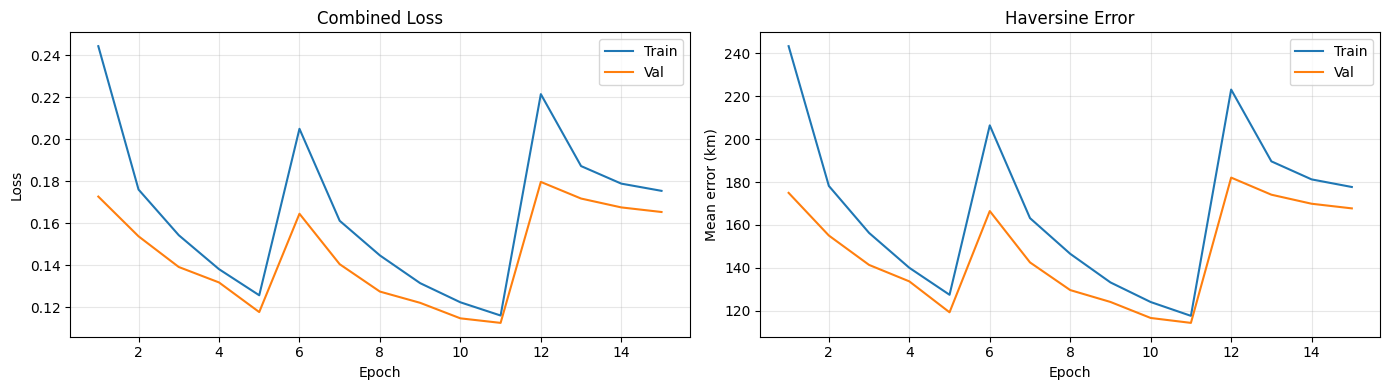

Saved: /content/drive/MyDrive/Vision_Project_2026/checkpoints_v3_2/training_curves.png


In [13]:
# Plot training curves
import matplotlib.pyplot as plt

if not history['train_loss']:
    print('No history yet.')
else:
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    ax1.plot(epochs, history['train_loss'], label='Train')
    ax1.plot(epochs, history['val_loss'],   label='Val')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title('Combined Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, history['train_km'], label='Train')
    ax2.plot(epochs, history['val_km'],   label='Val')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Mean error (km)')
    ax2.set_title('Haversine Error'); ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    out = os.path.join(DRIVE_CHECKPOINT_DIR, 'training_curves.png')
    plt.savefig(out, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Saved: {out}")


In [14]:
# Diagnostics -- run after a few epochs to verify gradient flow
import torch

model.train()
imgs, targets = next(iter(train_loader))
imgs, targets = imgs.to(device), targets.to(device)

optimizer.zero_grad()
with torch.cuda.amp.autocast(enabled=USE_AMP):
    preds = model(imgs)
    loss  = combined_loss(preds, targets)
loss.backward()

print(f"LR          : {optimizer.param_groups[0]['lr']:.2e}")
print(f"Loss (batch): {loss.item():.5f}")

grad_norms = [(n, p.grad.norm().item())
              for n, p in model.named_parameters()
              if p.requires_grad and p.grad is not None]

if not grad_norms:
    print('No gradients -- model may be fully frozen.')
else:
    print(f"\nActive gradient layers: {len(grad_norms)}")
    for name, norm in sorted(grad_norms, key=lambda x: -x[1])[:12]:
        flag = '  <<< near-zero' if norm < 1e-7 else ''
        print(f"  {norm:.4e}  {name}{flag}")

model.eval()
with torch.no_grad():
    out = model(imgs)
print(f"\nOutput range: [{out.min():.4f}, {out.max():.4f}]  (expected 0-1)")
optimizer.zero_grad()


/tmp/ipykernel_904/3706825121.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


LR          : 1.00e-06
Loss (batch): 0.17112

Active gradient layers: 211
  1.1615e+00  _orig_mod.geoclip.image_encoder.CLIP.vision_model.base_model.model.encoder.layers.6.self_attn.v_proj.lora_B.default.weight
  1.0532e+00  _orig_mod.geoclip.image_encoder.CLIP.vision_model.base_model.model.encoder.layers.3.self_attn.v_proj.lora_B.default.weight
  9.9902e-01  _orig_mod.geoclip.image_encoder.CLIP.vision_model.base_model.model.encoder.layers.3.self_attn.out_proj.lora_B.default.weight
  9.0514e-01  _orig_mod.geoclip.image_encoder.CLIP.vision_model.base_model.model.encoder.layers.4.self_attn.v_proj.lora_B.default.weight
  8.8743e-01  _orig_mod.geoclip.image_encoder.CLIP.vision_model.base_model.model.encoder.layers.5.self_attn.v_proj.lora_B.default.weight
  7.4945e-01  _orig_mod.geoclip.image_encoder.CLIP.vision_model.base_model.model.encoder.layers.7.self_attn.v_proj.lora_B.default.weight
  7.0579e-01  _orig_mod.geoclip.image_encoder.CLIP.vision_model.base_model.model.encoder.layers.6.self

## Section 5 -- Evaluation

Runs on the held-out **val** and **test** sets. The test set is identical to `GeoClip_Evaluation.ipynb` (same seed and split ratio).

In [15]:
import numpy as np
import torch
from tqdm import tqdm


def denorm(n_lat, n_lon):
    return (n_lat * (MAX_LAT - MIN_LAT) + MIN_LAT,
            n_lon * (MAX_LON - MIN_LON) + MIN_LON)


def haversine_np(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1; dlon = lon2 - lon1
    a    = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 6371 * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))


def macro_region(lat):
    if lat > 44.0:   return 'Nord'
    elif lat > 41.5: return 'Centro'
    else:            return 'Sud/Isole'


def evaluate(model, loader, label):
    model.eval()
    preds_list, true_list = [], []
    with torch.no_grad():
        for imgs, targets in tqdm(loader, desc=label, leave=False):
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                out = model(imgs.to(device)).cpu().numpy()
            preds_list.append(out)
            true_list.append(targets.numpy())

    preds = np.vstack(preds_list)
    trues = np.vstack(true_list)
    p_lat, p_lon = denorm(preds[:, 0], preds[:, 1])
    t_lat, t_lon = denorm(trues[:, 0], trues[:, 1])
    errors       = haversine_np(p_lat, p_lon, t_lat, t_lon)

    print(f"\n{'='*55}")
    print(f"  {label}  ({len(errors):,} images)")
    print(f"{'='*55}")
    print(f"  Mean   : {np.mean(errors):.1f} km")
    print(f"  Median : {np.median(errors):.1f} km")
    print(f"  90th   : {np.percentile(errors, 90):.1f} km")
    for th in [25, 50, 100, 200, 500]:
        print(f"  Within {th:>4} km : {np.mean(errors <= th)*100:.1f}%")
    return errors, p_lat, p_lon, t_lat, t_lon


val_errors, vp_lat, vp_lon, vt_lat, vt_lon = evaluate(model, val_loader,  'Validation set')
tst_errors, tp_lat, tp_lon, tt_lat, tt_lon = evaluate(model, test_loader, 'Test set (held-out)')


Validation set:   0%|          | 0/112 [00:00<?, ?it/s]/tmp/ipykernel_904/737163036.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):



  Validation set  (14,332 images)
  Mean   : 166.5 km
  Median : 127.2 km
  90th   : 348.4 km
  Within   25 km : 4.7%
  Within   50 km : 15.8%
  Within  100 km : 39.9%
  Within  200 km : 70.5%
  Within  500 km : 96.6%



  Test set (held-out)  (1,397 images)
  Mean   : 252.2 km
  Median : 207.8 km
  90th   : 503.4 km
  Within   25 km : 2.2%
  Within   50 km : 7.9%
  Within  100 km : 22.7%
  Within  200 km : 48.4%
  Within  500 km : 89.6%


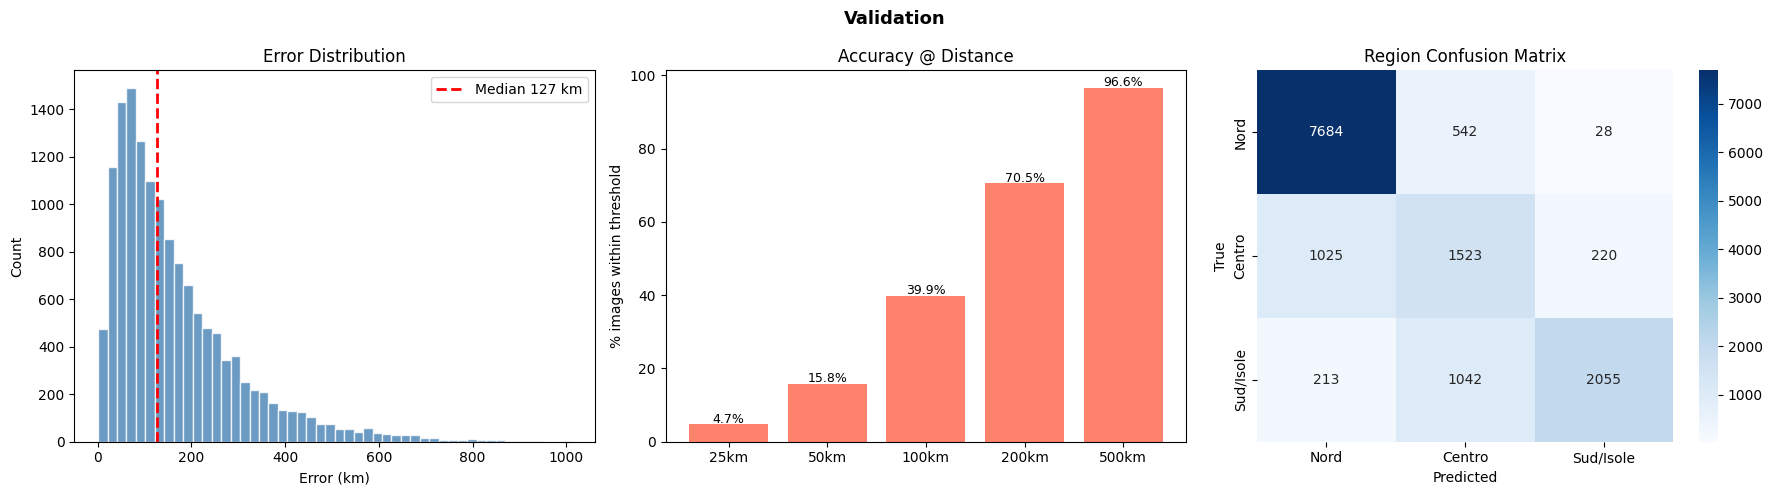

              precision    recall  f1-score   support

        Nord      0.861     0.931     0.895      8254
      Centro      0.490     0.550     0.518      2768
   Sud/Isole      0.892     0.621     0.732      3310

    accuracy                          0.786     14332
   macro avg      0.748     0.701     0.715     14332
weighted avg      0.797     0.786     0.785     14332



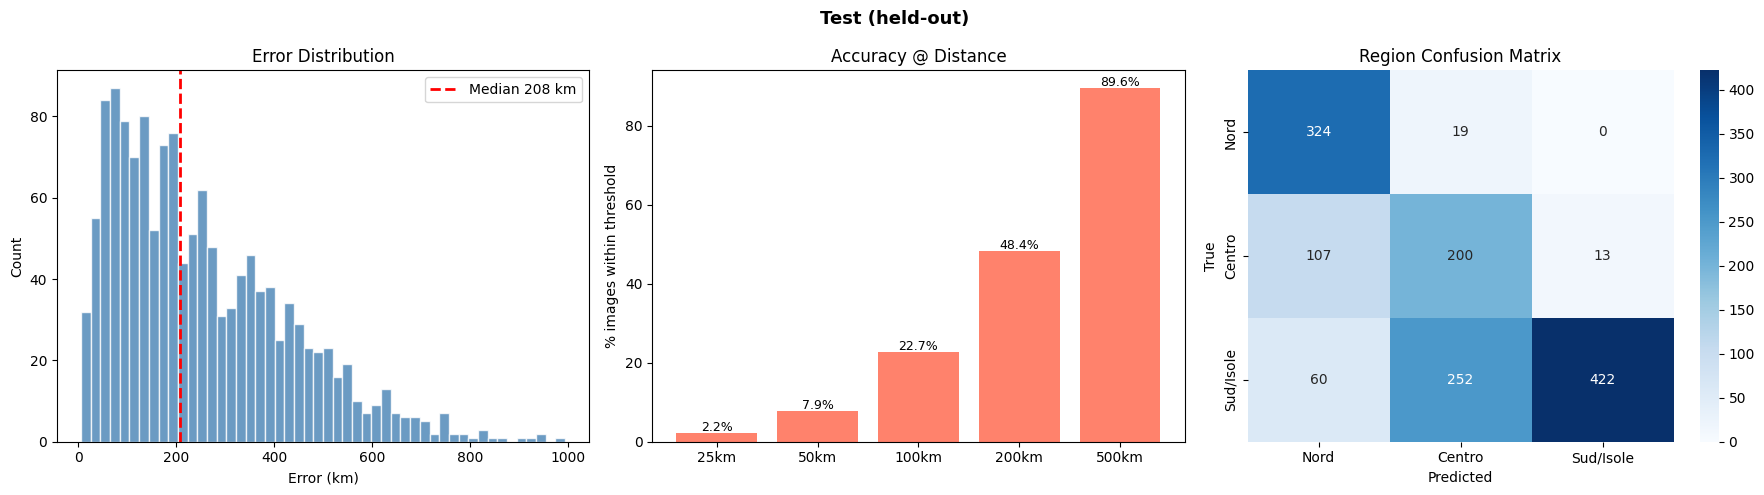

              precision    recall  f1-score   support

        Nord      0.660     0.945     0.777       343
      Centro      0.425     0.625     0.506       320
   Sud/Isole      0.970     0.575     0.722       734

    accuracy                          0.677      1397
   macro avg      0.685     0.715     0.668      1397
weighted avg      0.769     0.677     0.686      1397



In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix


def plot_eval(errors, p_lat, p_lon, t_lat, t_lon, title):
    labels = ['Nord', 'Centro', 'Sud/Isole']
    tr     = [macro_region(l) for l in t_lat]
    pr     = [macro_region(l) for l in p_lat]
    cm     = confusion_matrix(tr, pr, labels=labels)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    axes[0].hist(np.clip(errors, 0, 1200), bins=50, color='steelblue', alpha=0.8, edgecolor='white')
    axes[0].axvline(np.median(errors), color='red', lw=2, linestyle='--',
                    label=f'Median {np.median(errors):.0f} km')
    axes[0].set_xlabel('Error (km)'); axes[0].set_ylabel('Count')
    axes[0].set_title('Error Distribution'); axes[0].legend()

    ths  = [25, 50, 100, 200, 500]
    accs = [np.mean(errors <= t) * 100 for t in ths]
    bars = axes[1].bar([f'{t}km' for t in ths], accs, color='tomato', alpha=0.8)
    for bar, acc in zip(bars, accs):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{acc:.1f}%', ha='center', fontsize=9)
    axes[1].set_ylabel('% images within threshold')
    axes[1].set_title('Accuracy @ Distance')

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=axes[2])
    axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('True')
    axes[2].set_title('Region Confusion Matrix')

    plt.tight_layout()
    fname = os.path.join(DRIVE_CHECKPOINT_DIR, f"eval_{title.lower().replace(' ', '_')}.png")
    plt.savefig(fname, dpi=120, bbox_inches='tight')
    plt.show()
    print(classification_report(tr, pr, labels=labels, digits=3))


plot_eval(val_errors, vp_lat, vp_lon, vt_lat, vt_lon, 'Validation')
plot_eval(tst_errors, tp_lat, tp_lon, tt_lat, tt_lon, 'Test (held-out)')


In [17]:
# MC Dropout -- uncertainty estimation for a single image
# Set IMAGE_PATH and run.
import numpy as np
import os
import torch
from PIL import Image
from torchvision import transforms

IMAGE_PATH  = '/content/example.jpg'   # <-- change this
N_MC_PASSES = 50


def enable_dropout(m):
    for mod in m.modules():
        if mod.__class__.__name__.startswith('Dropout'):
            mod.train()


_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.48145466, 0.4578275, 0.40821073],
                         std=[0.26862954, 0.26130258, 0.27577711]),
])


def mc_dropout_predict(model, img_path, n=50):
    img    = Image.open(img_path).convert('RGB')
    tensor = _tf(img).unsqueeze(0).to(device)
    model.eval()
    enable_dropout(model)
    preds = []
    with torch.no_grad():
        for _ in range(n):
            out = model(tensor).cpu().numpy()[0]
            lat = out[0] * (MAX_LAT - MIN_LAT) + MIN_LAT
            lon = out[1] * (MAX_LON - MIN_LON) + MIN_LON
            preds.append([lat, lon])
    model.eval()
    return np.array(preds)


if os.path.exists(IMAGE_PATH):
    preds = mc_dropout_predict(model, IMAGE_PATH, n=N_MC_PASSES)
    print(f"Mean: lat={preds[:,0].mean():.4f}  lon={preds[:,1].mean():.4f}")
    print(f"Std : lat={preds[:,0].std():.4f}  lon={preds[:,1].std():.4f}")

    try:
        import folium
        from folium.plugins import HeatMap
        from IPython.display import display

        m = folium.Map(location=[preds[:,0].mean(), preds[:,1].mean()], zoom_start=7,
                       tiles='CartoDB dark_matter')
        HeatMap(preds.tolist(), radius=25, blur=15).add_to(m)
        folium.Marker([preds[:,0].mean(), preds[:,1].mean()],
                      popup='Mean prediction',
                      icon=folium.Icon(color='orange', icon='star')).add_to(m)
        display(m)
    except ImportError:
        print('folium not installed -- skipping map.')
else:
    print(f"Set IMAGE_PATH to an existing file. '{IMAGE_PATH}' not found.")


Set IMAGE_PATH to an existing file. '/content/example.jpg' not found.
